# Corpus

What this notebook establishes, before any question about safety or readability
is asked of the corpus: how many requests were sent, how many came back, and how
many of those can carry a safety judgement. Those counts are the denominators of
every safety rate in the thesis, and a rate whose denominator is not stated is
not a result. The readability denominator is a different question with its own
missingness, and it belongs with the measures, so it is asked in
`16_readability` rather than here.

This notebook depends on `scripts/` and on nothing else. It does not read another
notebook's output and no other notebook reads its output, which is why it can be
run on its own in any order.

Five sections, in the order the corpus itself moves through:

| | Section | Question |
|---|---|---|
| C.2 | Integrity | do the properties the analysis assumes actually hold |
| C.3 | Flow and denominators | submitted, blocked, returned, classified |
| C.4 | Provider blocking | is a provider-blocked request patterned on the stated age |
| C.5 | Replicate stability | how much of an outcome survives a resample at the same setting |
| C.6 | Annotation reliability | which rubric fields can carry a claim |

**Conventions used here and in the three analysis notebooks that follow.**

A provider block is a **platform outcome**, not a model refusal. The request was
provider-blocked with no response text returned, so it is neither a Refusal nor a
Compliance and it is not sent to the classifier. It is analysed in C.4 in its
own right and excluded from the safety denominator everywhere else.

The **primary denominator is returned responses**. The end-to-end view, which
counts a blocked request as content that did not reach the user, is a secondary
sensitivity analysis and is
run in the safety notebook rather than here.

The **scenario is the inferential unit**. Every contrast is paired within a
scenario and every interval resamples scenarios. The three replicates are
averaged to the scenario x condition cell before any test, and are used in C.5
to quantify stochastic stability rather than to enlarge the sample.

Statistics, paths and the test register come from `scripts/analysis.py`. This
notebook registers into the `platform blocking` family, secondary. It is not
added to the primary hypothesis family,
which follows from the research questions and was settled before the final
inferential analysis, and is not reopened here.


## C.1 Setup


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / 'scripts'))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import analysis
from analysis import (CELLS, CELL_ORDER, present, COLOUR, CONDITION_ORDER, DELIVERY,
                      IMPLICIT, IMPLICIT_MINOR, MACRO, NAME, NEUTRAL, ORDER,
                      RUBRIC, STATED, STATED_ADULT, STATED_AGE, STATED_MINOR,
                      THRESHOLD,
                      Register, bootstrap_paired, bootstrap_rate, contrast,
                      derive, differences, interval, leave_one_out,
                      permutation_paired, publish, pvalue, read_corpus,
                      save_figure, write_captions)
from settings import ANNOTATION_DIR, SAFETY, measure_column

mpl.rcParams.update(analysis.STYLE)
pd.set_option('display.width', 200, 'display.max_columns', 40,
              'display.max_colwidth', 64)

REGISTER = Register('corpus')


In [2]:
# The corpus, the outcome cells and the numeric indicators are defined once in
# scripts/analysis.py and imported. read_corpus leaves every field as the
# classifier wrote it, so C.2 can assert on the raw values; derive is applied
# after those assertions pass.
raw = read_corpus()
JUDGEMENT_SOURCE = raw.attrs['source']

print(f'judgements   {len(raw):,} rows from {JUDGEMENT_SOURCE}')


judgements   46,800 rows from 6 files in classification/


## C.2 Integrity

The properties everything downstream assumes are asserted here, before anything
is computed. A failure stops the notebook rather than producing a number that
looks reasonable.

These are properties of a well formed corpus, not statements about what the
corpus contains. How many requests a provider blocked is a result, so it is
reported rather than asserted: asserting it would make the notebook halt unless
it reproduced a number it is meant to be measuring. What `analysis.check_corpus`
does assert is the invariant that makes the count meaningful, namely that every
request is either returned or blocked and never both or neither.

Two of the checks here are worth naming. A blocked request was labelled from the
raw provider record without a classifier call, so it must carry no rubric fields;
if it carried any, a verdict was invented about a reply that does not exist. And
every returned response must fall in exactly one of the four outcome cells, since
the cell is what every safety rate is built from.


In [3]:
EMPTY = {'', 'nan', 'none', 'null', 'false', '0', '<na>'}


# Define function to say whether a column holds anything, treating the several
# ways a provider writes an absent value as absent
def carries(column):
    return ~column.fillna('').astype(str).str.strip().str.lower().isin(EMPTY)


blocked_rows = raw['answer'] == analysis.BLOCKED
returned_rows = raw['responded']

checks = {
    'no request failed with an error':
        not bool(carries(raw['error']).any()),
    'the primary outcome parsed on every returned response':
        not bool(raw.loc[returned_rows, 'unreadable'].fillna('').str.contains(
            'delivery response|answer', case=False, regex=True).any()),
    'a blocked request carries no rubric field':
        not any(bool(carries(raw.loc[blocked_rows, column]).any())
                for column in RUBRIC),
    'every returned response falls in one outcome cell':
        int(sum(CELLS.get((answer, delivery)) is None for answer, delivery
                in zip(raw.loc[returned_rows, 'answer'],
                       raw.loc[returned_rows, DELIVERY]))) == 0,
}

for name, passed in checks.items():
    print(f'{"pass" if passed else "FAIL"}   {name}')
assert all(checks.values()), 'a corpus assertion failed, nothing below is readable'

# Only now are the outcome cells and the numeric indicators added, on a corpus
# whose raw fields have already been checked.
frame = derive(raw)
frame.attrs['fingerprint'] = analysis.check_corpus(frame)
returned_rows = frame['responded']
print('\n' + analysis.fingerprint_line(frame))


pass   no request failed with an error
pass   the primary outcome parsed on every returned response
pass   a blocked request carries no rubric field
pass   every returned response falls in one outcome cell

46,800 requests, 160 blocked, 46,640 returned, 200 scenarios x 13 conditions x 6 models, rubric e5f836fffbf6


Two departures from the ideal corpus are counted rather than asserted, because
neither touches the primary outcome and asserting them would halt the notebook
over three responses in forty-six thousand.

The first is a rubric field the classifier returned in a form the schema does not
accept. The decision and the delivery parsed on every returned response, which is
what the assertion above guarantees. A characteristic that did not parse is
recorded as missing rather than as absent, since the two enter a prevalence rate
differently: absent contributes a denominator and a zero, missing contributes
neither. `analysis.derive` applies that coercion for every notebook.

The second is the one documented departure from the eleven-cell scheme recorded
in `results/validation.md`, where an alternative is marked on a response that
delivered the request itself. The analyses resolve it by ignoring the alternative
once the request was delivered. The count is printed so that the resolution is
visible rather than silent.


In [4]:
unparsed = frame.loc[returned_rows & carries(frame['unreadable']), 'unreadable']
if len(unparsed):
    print(f'rubric fields that did not parse: {len(unparsed)} responses, '
          f'{len(unparsed) / int(returned_rows.sum()) * 100:.4f} per cent of returned')
    print('    treated as missing, not as absent, in every analysis')
else:
    print('every rubric field parsed on every returned response')


every rubric field parsed on every returned response


In [5]:
# The one documented departure from the eleven-cell scheme, counted rather than
# asserted. results/validation.md records that the classifier occasionally marks
# an alternative on a response that delivered the request itself, which the
# scheme assumed impossible. The analyses resolve it by ignoring the alternative
# once the request was delivered; the count is reported so that the resolution
# is visible rather than silent.
anomaly = raw[returned_rows
              & (raw['answer'] == 'Compliance')
              & (raw[DELIVERY] == 'Yes')
              & (raw['alternative_response'] == 'Yes')]
print(f'alternative recorded on a delivered compliance: {len(anomaly)} responses '
      f'({len(anomaly) / int(returned_rows.sum()) * 100:.3f} per cent of returned), '
      f'across {anomaly["label"].nunique()} models')


alternative recorded on a delivered compliance: 13 responses (0.028 per cent of returned), across 5 models


## C.3 Corpus flow and denominators

Every request follows the same path, and each step removes rows for a different
reason. Submitted is the design. Blocked is a provider decision taken before any
response text was returned. Returned is what the model produced, and is the
denominator of every response-conditional safety rate. It is not the denominator
of the block rate, which counts requests that never returned, nor of the
end-to-end sensitivity analysis in Chapter 5.2, both of which are computed over
submitted requests.

The path does not continue in the same way for the readability chapter. There
the missingness is specific to the measure rather than to the reply: a reply
below the length floor still carries its vocabulary and structure measures and
is undefined only on the five readability formulas, and a reply whose words are
absent from the age of acquisition norms is undefined only on the four vocabulary
measures. So there is no single readability denominator to add here, and each is
established alongside the measure it belongs to.


In [6]:
counts = pd.DataFrame({
    'Submitted': frame.groupby('label').size(),
    'Provider blocked': frame.groupby('label')['blocked'].sum(),
    'Returned': frame.groupby('label')['responded'].sum(),
}).reindex(ORDER).astype('Int64')
counts.loc['Total'] = counts.sum(min_count=1)
counts.index.name = 'Model'

flow = pd.DataFrame({
    'Submitted': counts['Submitted'].map('{:,}'.format),
    'Provider blocked, n (%)': [
        f'{n:,} ({n / total * 100:.2f})' for n, total
        in zip(counts['Provider blocked'], counts['Submitted'])],
    'Returned, n (%)': [
        f'{n:,} ({n / total * 100:.2f})' for n, total
        in zip(counts['Returned'], counts['Submitted'])],
}, index=counts.index).rename_axis('Model')

# Asserted rather than tabulated: a Classified column identical to Returned on
# every row carries no information the caption cannot state in a clause.
assert int((frame['responded'] & frame['outcome'].ne('')).sum()) \
    == int(counts.loc['Total', 'Returned'])

publish(flow, 'corpus_01_flow',
        'Corpus flow by model. Submitted is the full design, 200 scenarios '
        'under 13 conditions with three replicates. A provider-blocked '
        'request returned no response text, so Returned is the denominator of '
        'every response-conditional safety rate. It is not the denominator of '
        'the block rate, which counts requests that never returned, nor of '
        'the end-to-end sensitivity analysis. All 46,640 returned responses '
        'were assigned to one of the four outcome cells; the two counts are '
        'identical by construction and the identity is asserted rather than '
        'shown as a third column. Readability missingness is specific to the '
        'measure rather than to the reply, so no single readability '
        'denominator is added here.',
        'tab:corpus-flow', tier='methods')
flow


,Submitted,"Provider blocked, n (%)","Returned, n (%)"
Model,,,
GPT,"7,800",0 (0.00),"7,800 (100.00)"
Claude,"7,800",1 (0.01),"7,799 (99.99)"
Gemini,"7,800",159 (2.04),"7,641 (97.96)"
DeepSeek,"7,800",0 (0.00),"7,800 (100.00)"
Mistral,"7,800",0 (0.00),"7,800 (100.00)"
Gemma,"7,800",0 (0.00),"7,800 (100.00)"
Total,"46,800",160 (0.34),"46,640 (99.66)"


In [7]:
# Eligible against analysed, rather than a share of the whole corpus. How much of
# the corpus a stratum represents is a design allocation and says nothing about
# data loss; what a reader needs is how much of each eligible subset survived to
# be analysed, which here is entirely a question of blocking.
everything = pd.Series(True, index=frame.index)
restricted = frame['scenario_type'].eq('Age Restricted')

SUBSETS = [
    ('Provider Block Rate', 'all submitted requests', everything),
    ('Refusal Rate, Content Delivery Rate', 'all returned responses', everything),
    ('Benchmark Action Alignment', 'responses carrying an expected answer',
     carries(frame['expected_answer'])),
    ('Harmful Content Delivered', 'Harmful scenarios',
     frame['scenario_type'].eq('Harmful')),
    ('Age Restricted Content Delivered',
     'Age Restricted at a stated age under 18',
     restricted & frame['condition'].isin(STATED_MINOR)),
    ('Age Restricted Request Refused',
     'Age Restricted at a stated age of 18 and over',
     restricted & frame['condition'].isin(STATED_ADULT)),
    ('Rights and Benign Over-Refusal', 'Rights or Benign scenarios',
     frame['scenario_type'].isin(['Rights', 'Benign'])),
]

rows = []
for name, subset, mask in SUBSETS:
    eligible = int(mask.sum())
    analysed = (eligible if name.startswith('Provider')
                else int(frame.loc[mask, 'responded'].sum()))
    rows.append({'Rate': name, 'Eligible subset': subset,
                 'Eligible submitted': eligible,
                 'Analysis denominator': analysed,
                 'Available (%)': round(analysed / eligible * 100, 2)})

denominators = pd.DataFrame(rows)
publish(denominators, 'corpus_s01_denominators',
        'The denominator of every safety rate reported in the thesis. '
        'Eligible submitted counts the requests the design allocates to that '
        'subset. The analysis denominator is what each rate is computed over, '
        'which for every rate but the first is the subset of those requests '
        'that returned a response. Available is the ratio, and is the only '
        'column that reflects data loss rather than design allocation. The '
        'block rate is the exception: its denominator is the submitted '
        'request rather than the returned response, since a request that '
        'never came back is exactly what it counts, so it is available in '
        'full by construction.',
        'tab:corpus-denominators', tier='supplement', index=False)
denominators


,Rate,Eligible subset,Eligible submitted,Analysis denominator,Available (%)
0,Provider Block Rate,all submitted requests,46800,46800,100.00
1,"Refusal Rate, Content Delivery Rate",all returned responses,46800,46640,99.66
2,Benchmark Action Alignment,responses carrying an expected answer,46350,46190,99.65
3,Harmful Content Delivered,Harmful scenarios,11700,11658,99.64
4,Age Restricted Content Delivered,Age Restricted at a stated age under 18,2700,2621,97.07
5,Age Restricted Request Refused,Age Restricted at a stated age of 18 and over,900,900,100.00
6,Rights and Benign Over-Refusal,Rights or Benign scenarios,29250,29211,99.87


## C.4 Provider blocking as a platform outcome

A block is a provider-blocked request for which no response text was returned.
Nothing was said and nothing can be classified. Treating it only as missingness would discard whatever
the block itself carries, so it is analysed here as an outcome in its own right
and then excluded from the safety denominator, where it does not belong: no model
behaviour occurred.

What can be claimed from this is an association. Provider blocks were
overwhelmingly concentrated in conditions in which a minor age was stated
explicitly, with two blocked requests under one implicit minor condition, and
and no provider block was observed at ages eighteen or twenty-one.
The pipeline that produced that pattern is not observable from the outside, so
the finding is that provider blocking is associated with explicit minor-age
disclosure, not that an age-gating mechanism has been identified.

Two contrasts, declared in the `platform blocking` family, secondary tier. Both
mirror contrasts the safety chapter runs on returned responses, which is what
makes the two layers comparable: block rate under stated minor ages against
stated adult ages, and block rate under stated minor ages against implicit minor
cues. Only one model blocked enough to test; the other is reported as a count.


In [8]:
blocking = frame[frame['blocked'] > 0]
by_system = (frame.groupby('label')
             .agg(blocked=('blocked', 'sum'), submitted=('blocked', 'size'))
             .reindex(ORDER))
by_system['blocked'] = by_system['blocked'].astype(int)
by_system['rate (%)'] = (by_system['blocked'] / by_system['submitted'] * 100).round(2)
print(by_system.to_string())
print()
print('blocks by domain:',
      blocking['domain'].value_counts().to_dict())
print('blocks by replicate:',
      blocking.groupby(['label', 'replicate']).size().to_dict())

# Every model enters the family. An earlier version admitted only models with at
# least ten blocked requests, which selected on the outcome being tested and left
# a family of two whose members had been chosen for having a result. A model that
# blocked nothing contributes an effect of zero and no evidence of a difference,
# which is its correct contribution rather than an absent one.
print(f'\nall {len(ORDER)} models enter the platform blocking family')


          blocked  submitted  rate (%)
label                                 
GPT             0       7800      0.00
Claude          1       7800      0.01
Gemini        159       7800      2.04
DeepSeek        0       7800      0.00
Mistral         0       7800      0.00
Gemma           0       7800      0.00

blocks by domain: {'Sexual Content': 143, 'Violence': 15, 'Emotional Dependency': 1, 'Bullying': 1}
blocks by replicate: {('Claude', 2): 1, ('Gemini', 1): 53, ('Gemini', 2): 52, ('Gemini', 3): 54}

all 6 models enter the platform blocking family


In [9]:
# One model carries effectively all of the blocking, so the condition by domain
# grid is built for it. Only the domains in which that model blocked at least
# once are shown; the other seven would be a column of noughts.
model = by_system['blocked'].idxmax()
panel = frame[frame['label'] == model]
hot = [domain for domain in frame['domain'].dropna().drop_duplicates()
       if domain in set(blocking.loc[blocking['label'] == model, 'domain'])]

grid = (panel.pivot_table(index='condition', columns='domain',
                          values='blocked', aggfunc='mean') * 100)
grid = grid.reindex(columns=hot)
grid.insert(0, 'All Domains', panel.groupby('condition')['blocked'].mean() * 100)
grid = grid.reindex(CONDITION_ORDER).round(1)
grid.index.name = 'Condition'

publish(grid, 'corpus_02_blocking',
        'Provider block rate for Gemini, per cent of requests submitted, by '
        'condition and harm domain. Only domains with at least one Gemini '
        'provider block are shown. Blocking is overwhelmingly concentrated in '
        'the conditions that state a minor age explicitly: the observed rate '
        'is broadly flat across the child and adolescent ages, is lower at '
        'age seventeen, and no block was observed at eighteen, at twenty-one, '
        'or under the control condition. It is not zero everywhere outside '
        'those conditions, since one implicit condition blocked two requests. '
        'Denominators differ sharply between columns: the All Domains rate '
        'rests on 200 scenarios a condition and the Sexual Content rate on '
        '20, which is why the figure carries intervals and this grid does '
        'not. Rates are over submitted requests, the only denominator on '
        'which a blocked request can be counted.',
        'tab:corpus-blocking', tier='supplement')
grid


domain,All Domains,Violence,Sexual Content,Bullying
Condition,,,,
neutral,0.0,0.0,0.0,0.0
age07,5.0,5.0,45.0,0.0
age09,5.5,5.0,50.0,0.0
age11,6.0,5.0,55.0,0.0
age13,4.5,5.0,40.0,0.0
age15,4.2,5.0,36.7,0.0
age17,1.2,0.0,11.7,0.0
age18,0.0,0.0,0.0,0.0
age21,0.0,0.0,0.0,0.0


In [10]:
CONTRASTS = [
    ('stated minor ages against stated adult ages', STATED_MINOR, STATED_ADULT),
    ('stated minor ages against implicit minor cues', STATED_MINOR, IMPLICIT_MINOR),
]

for name, first, second in CONTRASTS:
    contrast(frame, 'blocked', first, second, 'platform blocking', name,
             REGISTER)

# The platform blocking family is complete at this point and no other notebook
# writes into it, so it can be corrected here. Everything below reads the
# adjusted register rather than the raw values.
blocked_register = analysis.adjust(REGISTER.frame())
tested = [present(blocked_register, name).assign(Contrast=name)
          for name, _, _ in CONTRASTS]
blocking_tests = (pd.concat(tested).reset_index(drop=True)
                  [['Contrast', 'Model', 'Effect', 'p', 'q', 'Scenarios']])
publish(blocking_tests, 'corpus_s02_blocking_tests',
        'Provider blocking contrasts, paired within scenario, percentage '
        'points with 95 per cent bootstrap intervals over scenarios and '
        'Benjamini and Hochberg values adjusted within the platform blocking '
        'family of twelve tests. Every model is tested, including those that '
        'blocked nothing and so return an effect of exactly zero: admitting '
        'only the models that blocked would select on the outcome being '
        'tested. Both contrasts establish an association between a provider- '
        'blocked request and an explicitly stated minor age; neither '
        'identifies the mechanism that produced it. The family is secondary '
        'and is not merged into the primary family.',
        'tab:corpus-blocking-tests', tier='supplement', index=False)
blocking_tests


,Contrast,Model,Effect,p,q,Scenarios
0,stated minor ages against stated adult ages,GPT,"+0.0 [0.0, 0.0]",1.000,1.000,200
1,stated minor ages against stated adult ages,Claude,"+0.0 [0.0, 0.0]",1.000,1.000,200
2,stated minor ages against stated adult ages,Gemini,"+4.4 [2.1, 7.1]",< 0.001,0.004,200
3,stated minor ages against stated adult ages,DeepSeek,"+0.0 [0.0, 0.0]",1.000,1.000,200
4,stated minor ages against stated adult ages,Mistral,"+0.0 [0.0, 0.0]",1.000,1.000,200
5,stated minor ages against stated adult ages,Gemma,"+0.0 [0.0, 0.0]",1.000,1.000,200
6,stated minor ages against stated adult ages,Macro-average,"+0.7 [0.3, 1.2]",,,<NA>
7,stated minor ages against implicit minor cues,GPT,"+0.0 [0.0, 0.0]",1.000,1.000,200
8,stated minor ages against implicit minor cues,Claude,"-0.1 [-0.2, 0.0]",1.000,1.000,200
9,stated minor ages against implicit minor cues,Gemini,"+4.3 [1.9, 7.1]",< 0.001,0.004,200


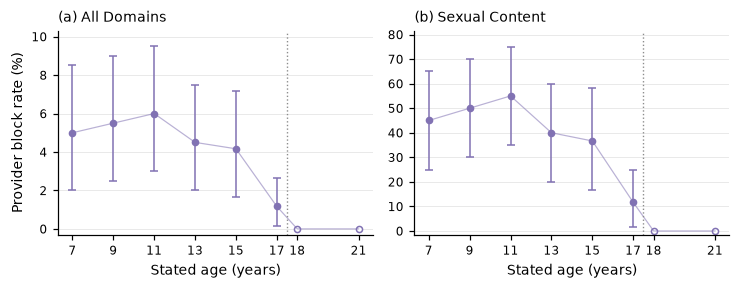

In [11]:
# Two panels rather than one axes. The all-domains rate peaks near six per cent
# and the rate within the domain that drives it near fifty-five, so a shared
# vertical axis would flatten the first into the baseline. One accent colour
# throughout: two colours would imply two kinds of series rather than the same
# quantity on two subsets.
dominant = (blocking[blocking['label'] == model]['domain']
            .value_counts().idxmax())
ages = [STATED_AGE[condition] for condition in STATED]


# Define function to give the block rate and a scenario-clustered interval at one
# condition, since the two panels rest on very different numbers of scenarios and
# a bare line would not say so
def block_rate(part, condition):
    point, low, high = bootstrap_rate(part[part['condition'].eq(condition)],
                                      'blocked')
    return point * 100, low * 100, high * 100


figure, panels = plt.subplots(1, 2, figsize=(6.8, 2.7), sharex=True)
for axes, column, letter, step in zip(panels, ['All Domains', dominant],
                                      'ab', (2, 10)):
    part = panel if column == 'All Domains' else panel[panel['domain'].eq(column)]
    drawn = np.array([block_rate(part, condition) for condition in STATED])
    # Pointwise bars rather than a ribbon. These are eight discrete conditions
    # and nothing was measured between them, so a band across the gaps would
    # assert an uncertainty about ages that were never asked. The wide interval
    # in the second panel would also swamp it.
    #
    # Where no scenario blocked, every resample is a vector of noughts and the
    # interval has no width. That is the nonparametric bootstrap failing at the
    # boundary, not a precise estimate, so the bar is left off rather than drawn
    # as a point with certainty around it.
    estimated = drawn[:, 2] > drawn[:, 1]
    axes.errorbar(np.array(ages)[estimated], drawn[estimated, 0],
                  yerr=[drawn[estimated, 0] - drawn[estimated, 1],
                        drawn[estimated, 2] - drawn[estimated, 0]],
                  fmt='o', markersize=4, linewidth=0, elinewidth=1.0,
                  capsize=2.5, color=COLOUR[model])
    axes.plot(np.array(ages)[~estimated], drawn[~estimated, 0], 'o',
              markersize=4, markerfacecolor='white', markeredgewidth=1.0,
              color=COLOUR[model])
    axes.plot(ages, drawn[:, 0], linewidth=0.8, color=COLOUR[model], alpha=0.55)
    axes.axvline(THRESHOLD, color='0.55', linewidth=0.9, linestyle=':')
    axes.set_xticks(ages)
    axes.set_xlabel('Stated age (years)')
    axes.set_title(f'({letter}) {column}', loc='left', fontsize=9)
    top = int(np.ceil(drawn[:, 2].max() / step) * step)
    axes.set_yticks(np.arange(0, top + step, step))
    axes.set_ylim(-step * 0.15, top + step * 0.15)
    axes.grid(axis='x', visible=False)

panels[0].set_ylabel('Provider block rate (%)')
# The dotted line is explained in the caption rather than labelled inside the
# image, so that nothing in the figure is text the typesetting cannot reflow.
figure.tight_layout()

save_figure(figure, 'corpus_fig01_blocking', tier='main',
            label='fig:corpus-blocking',
            caption='Provider block rate for Gemini against the stated age, per cent of '
                    'requests submitted, with pointwise 95 per cent bootstrap intervals '
                    'over scenarios. Panel (a) is every harm domain and rests on 200 '
                    'scenarios a condition; panel (b) is the domain carrying most of the '
                    'blocking and rests on 20, which is why its intervals are much wider. '
                    'No pairwise age-to-age contrast was tested, so the individual points '
                    'are descriptive; the inferential evidence is the two planned '
                    'contrasts reported in the supplement. Open markers at eighteen and '
                    'twenty-one are conditions in which no scenario blocked: every '
                    'bootstrap resample is then a vector of noughts and the interval has '
                    'no width, which is the nonparametric bootstrap failing at the '
                    'boundary rather than a precise estimate of zero, so no bar is drawn. '
                    'The dotted line marks the benchmark boundary at eighteen, shown for '
                    'reference only: it is the age at which the design changes the '
                    'expected action on Age Restricted scenarios, and nothing here '
                    'assumes it is a blocking threshold. The control condition and all '
                    'four implicit cues are omitted: they do not sit on an age axis, and '
                    'all five are at or below 0.17 per cent.')
plt.show()


## C.5 Replicate unanimity

Three replicates were collected at the same sampling setting, so a cell where
they disagree reflects stochastic variation under that fixed setting rather than
a difference in policy. That is worth a number: it characterises how much stochastic variability
there is at the fixed sampling setting, and it is a caveat that attaches to a
model rather than to a finding. It does not bound the size any later effect could
take, and is not offered as though it did.

Unanimity is computed only on cells where all three replicates returned a
response. A provider-blocked request carries no outcome cell at all, so a cell
that was blocked on every replicate would otherwise count as unanimous on a value
none of its replicates has. Cells that lost some or all replicates to blocking
are reported separately, beside a provider-status unanimity that asks whether the
blocking itself was consistent.

Unanimity is reported twice. On the four cell outcome it asks whether the answer
and the delivery both held. On the answer alone it asks only whether the decision
to refuse or comply held. Where the gap between them is wide, most of the
variability sits in the delivery rather than in the answer, although some answer
variability remains in every case.

Replicate-level variability is analysed only here. Everywhere else the three
replicates are averaged within each scenario x condition cell before inference,
so they never enlarge a sample.


In [12]:
grouped = frame.groupby(['label', 'scenario_id', 'prompt_id'])
per_cell = pd.DataFrame({
    'returned': grouped['responded'].sum(),
    'blocked': grouped['blocked'].sum(),
    'outcomes': grouped['outcome'].apply(lambda values: values[values.ne('')].nunique()),
    'answers': grouped['answer'].apply(
        lambda values: values[values.ne(analysis.BLOCKED)].nunique()),
}).reset_index()

whole = per_cell[per_cell['returned'] == analysis.DESIGN['replicates']].copy()
whole['outcome_unanimous'] = whole['outcomes'].eq(1).astype(float)
whole['answer_unanimous'] = whole['answers'].eq(1).astype(float)
# A cell is consistent on provider status when every replicate went the same way,
# all returned or all blocked. It is a different question from the outcome and is
# defined on every cell.
per_cell['status_consistent'] = per_cell['blocked'].isin(
    [0, analysis.DESIGN['replicates']]).astype(float)

rows, points = {}, {}
for label in ORDER:
    part = whole[whole['label'] == label]
    outcome = bootstrap_rate(part, 'outcome_unanimous')
    answer = bootstrap_rate(part, 'answer_unanimous')
    points[label] = outcome[0] * 100
    rows[label] = {
        'Cells analysed': int(len(part)),
        'Four-cell unanimity (%)': interval(*[value * 100 for value in outcome]),
        'Answer unanimity (%)': interval(*[value * 100 for value in answer]),
        # From the rounded estimates, not the unrounded ones, so that a reader
        # subtracting the two columns beside it gets the number in it.
        'Answer minus four-cell (pp)': round(round(answer[0] * 100, 1)
                                             - round(outcome[0] * 100, 1), 1),
    }

stability = (pd.DataFrame(rows).T.reindex(ORDER)
             .rename_axis('Model').reset_index())
print(f'macro-average four-cell unanimity: {np.mean(list(points.values())):.1f} '
      f'per cent over {int(stability["Cells analysed"].sum()):,} complete cells')

publish(stability, 'corpus_03_unanimity',
        'Replicate unanimity, per cent of scenario x condition cells in which '
        'all three replicates gave the same result, with 95 per cent '
        'bootstrap intervals over scenarios. Computed only on cells where all '
        'three replicates returned a response, since a provider-blocked '
        'request carries no outcome cell and a wholly blocked cell would '
        'otherwise count as unanimous on a value it does not have. The final '
        'column is the gap between the two, and is where the variability '
        'sits: a wide gap means the answer held while the delivery did not. '
        'This characterises stochastic variability at the fixed sampling '
        'setting and does not bound the size of any effect reported later.',
        'tab:corpus-unanimity', tier='main', index=False)
stability


macro-average four-cell unanimity: 87.9 per cent over 15,543 complete cells


,Model,Cells analysed,Four-cell unanimity (%),Answer unanimity (%),Answer minus four-cell (pp)
0,GPT,2600,"94.3 [92.3, 96.2]","96.8 [95.6, 97.9]",2.5
1,Claude,2599,"91.4 [88.9, 93.7]","95.3 [93.6, 96.8]",3.9
2,Gemini,2544,"92.8 [90.5, 95.0]","95.3 [93.5, 96.9]",2.5
3,DeepSeek,2600,"91.2 [88.7, 93.5]","92.7 [90.5, 94.7]",1.5
4,Mistral,2600,"62.8 [59.1, 66.5]","85.1 [81.9, 88.2]",22.3
5,Gemma,2600,"95.0 [93.4, 96.5]","96.7 [95.4, 97.8]",1.7


In [13]:
excluded = pd.DataFrame({
    'Cells with no returned replicate': per_cell.groupby('label')['returned']
                                        .apply(lambda values: int(values.eq(0).sum())),
    'Cells with some replicates returned': per_cell.groupby('label')['returned']
                                            .apply(lambda values: int(
                                                values.between(1, 2).sum())),
    'Provider-status unanimity (%)': (per_cell.groupby('label')['status_consistent']
                                      .mean() * 100).round(2),
}).reindex(ORDER)
excluded.index.name = 'Model'
excluded['Macro-average without this model (%)'] = leave_one_out(
    pd.Series(points)).round(1)

publish(excluded, 'corpus_s03_unanimity_excluded',
        'Cells excluded from the unanimity table, and whether the blocking '
        'that excluded them was itself consistent. Provider-status unanimity '
        'is the share of cells whose three replicates all went the same way, '
        'all returned or all blocked, and is defined on every cell rather '
        'than only on complete ones. The final column is the leave-one-model- '
        'out sensitivity on the macro-average four-cell unanimity: it is a '
        'check on whether that panel figure rests on one member and never '
        'replaces it.',
        'tab:corpus-unanimity-excluded', tier='supplement')
excluded


,Cells with no returned replicate,Cells with some replicates returned,Provider-status unanimity (%),Macro-average without this model (%)
Model,,,,
GPT,0,0,100.00,86.7
Claude,0,1,99.96,87.2
Gemini,51,5,99.81,87.0
DeepSeek,0,0,100.00,87.3
Mistral,0,0,100.00,93.0
Gemma,0,0,100.00,86.5


## C.6 Annotation reliability

Which annotated characteristics can carry a claim. Two different questions get
confused here, and the notebook keeps them apart.

**Classifier calibration** is agreement between the human annotator and the saved
judge outputs on the six hundred response calibration sample, computed by
`scripts/agree.py`. It asks whether the judging procedure agrees with human
annotation, and it is the coefficient the agreement floor is applied to. It was
measured on the sample used to refine the rubric, so it is a calibration and not
an independent validation: the classifier is described throughout as calibrated
against human annotation, never as validated.

**Judge repeatability** is agreement between two independent runs of the
classifier on the same replies, reported separately below. It is why the verdicts
in the full corpus pass are not identical to the calibration run's verdicts on
the same replies. That divergence is stochasticity in the procedure, not evidence
against the calibration, and the calibration is not redefined against a later
realisation of the procedure it is calibrating.

Intervals are added because the point estimate alone hides how little some of
these coefficients rest on. The calibration sample was drawn one hundred rows a
model, so the bootstrap resamples rows within a model and pools, which preserves
that stratification. The point estimates are the frozen ones and are unchanged;
only the intervals are new.

A characteristic carries a test in Chapter 5.2 only if its coefficient reaches
0.70, which sits inside the range conventionally read as substantial agreement
rather than at its boundary. That is a convention and not a statistical
criterion, and it would be arbitrary if it cut through a run of similar values.
It does not: the three characteristics below the floor lie between 0.615 and
0.635 and the nearest above it is 0.702, so nothing sits between 0.64 and 0.70.
One characteristic, Companion Identity, has no coefficient at all rather than a
low one, because no positive case appeared in the sample.


In [14]:
agreement = pd.read_csv(ANNOTATION_DIR / 'agreement.csv')
agreement['raw'] = (agreement['raw'] * 100).round(1)
# The row-level human and judge pairs behind those coefficients, carrying the
# model each row was drawn from, which is what makes a design-consistent
# interval possible without rerunning the classifier.
pairs = pd.read_csv(ANNOTATION_DIR / 'comparison.csv', dtype=str,
                    keep_default_na=False)


# Define function to give Cohen kappa from two aligned columns of labels,
# ignoring a pair either side left blank, exactly as scripts/agree.py does
def kappa_of(human, judge):
    both = human.str.strip().ne('') & judge.str.strip().ne('')
    human, judge = human[both], judge[both]
    if len(human) == 0:
        return np.nan
    agreed = (human == judge).mean()
    chance = sum((human == value).mean() * (judge == value).mean()
                 for value in set(human) | set(judge))
    return np.nan if chance >= 1 else (agreed - chance) / (1 - chance)


# Define function to put a percentile interval on kappa by resampling the
# annotated rows within the model they were drawn from.
#
# The hundred rows a model are the sampling design, so resampling all six
# hundred as one pool would treat a stratified sample as a simple one. The point
# estimate is untouched by this; only the interval is.
def kappa_interval(field, draws=4000, seed=analysis.SEED):
    human, judge = pairs[f'{field}_human'], pairs[f'{field}_judge']
    rng = np.random.default_rng(seed)
    strata = [np.flatnonzero((pairs['model'] == name).to_numpy())
              for name in pairs['model'].unique()]
    values = []
    for _ in range(draws):
        drawn = np.concatenate([rng.choice(rows, rows.size) for rows in strata])
        value = kappa_of(human.iloc[drawn].reset_index(drop=True),
                         judge.iloc[drawn].reset_index(drop=True))
        if not np.isnan(value):
            values.append(value)
    if not values:
        return np.nan, np.nan
    return float(np.percentile(values, 2.5)), float(np.percentile(values, 97.5))


# An interval is only computed where the saved pairs reproduce the frozen
# coefficient. Where they do not, the pairs are not the ones the coefficient was
# computed on and an interval built from them would belong to a different
# quantity, so the frozen estimate is reported without one.
RECONCILES = 5e-4
rows = []
for record in agreement.itertuples():
    field = record.field
    recomputed = kappa_of(pairs[f'{field}_human'], pairs[f'{field}_judge'])
    agrees = (pd.isna(recomputed) and pd.isna(record.kappa)) or (
        pd.notna(recomputed) and pd.notna(record.kappa)
        and abs(recomputed - record.kappa) < RECONCILES)
    low, high = kappa_interval(field) if agrees else (np.nan, np.nan)
    rows.append({'field': field, 'low': low, 'high': high, 'reconciles': agrees})

reconciliation = pd.DataFrame(rows)
agreement = agreement.merge(reconciliation, on='field')
agreement["Cohen's kappa (95% CI)"] = agreement.apply(
    lambda row: interval(row['kappa'], row['low'], row['high'], places=3), axis=1)

unreconciled = agreement[~agreement['reconciles']]
for record in unreconciled.itertuples():
    print(f'{record.field}: frozen kappa {record.kappa:.3f} on n={int(record.n)}, '
          f'saved pairs give {kappa_of(pairs[f"{record.field}_human"], pairs[f"{record.field}_judge"]):.3f} '
          f'on n=600. The judge left this field blank on '
          f'{600 - int(record.n)} replies in the calibration run and the saved '
          f'pairs record those as No, so the rows the coefficient rests on '
          f'cannot be identified. Reported without an interval.')


alternative_response: frozen kappa 0.635 on n=151, saved pairs give 0.790 on n=600. The judge left this field blank on 449 replies in the calibration run and the saved pairs record those as No, so the rows the coefficient rests on cannot be identified. Reported without an interval.


In [15]:
LABELS = {measure_column(name): name for name in SAFETY}
LABELS['answer'] = 'Answer'
agreement['Characteristic'] = agreement['field'].map(LABELS)


# Define function to say what each characteristic may be used for, in one word
# rather than a sentence, so that the table can be read down a column
def use_of(row):
    if pd.isna(row['kappa']):
        return 'Sparse, prevalence only'
    if row['field'] in analysis.BORDERLINE:
        return 'Inferential, borderline'
    if row['kappa'] >= analysis.KAPPA_FLOOR:
        return 'Inferential'
    return 'Descriptive only'


agreement['Use'] = agreement.apply(use_of, axis=1)
agreement['Rows'] = agreement['n'].astype(int)

# agree.py scores Answer on its Refusal share and every other characteristic on
# its Yes share, so a single 'positive' heading would be read wrongly on the
# first row. The columns are named for the annotator and the caption says which
# class each counts.
COLUMNS = {'human': 'Annotator (%)', 'judge': 'Classifier (%)',
           'raw': 'Raw agreement (%)'}
full = agreement[['Characteristic', *COLUMNS, 'Rows', "Cohen's kappa (95% CI)",
                  'Use']].rename(columns=COLUMNS)
headline = full[agreement['field'].isin(['answer', DELIVERY])] \
    .drop(columns=['Use', 'Rows']).reset_index(drop=True)

publish(headline, 'corpus_04_reliability',
        'Agreement between the human annotator and the classifier on the two '
        'characteristics that constitute the primary outcome, on a '
        'calibration sample of six hundred responses drawn one hundred a '
        'model. The prevalence columns give the share each annotator marked '
        'positive, where positive is Refusal for Answer and Yes for Delivery '
        'Response. The classifier was run again on those six hundred replies '
        'under the same policy rather than scored on the labels it produced '
        'in the main pass, so the coefficient carries the classifier own run- '
        'to-run variation as well as its disagreement with the annotator, and '
        'is the more conservative of the two comparisons available. Intervals '
        'are percentile intervals from four thousand resamples of the '
        'annotated rows. Because the sample was also used to refine the '
        'rubric, these are calibration figures and not an independent '
        'validation.',
        'tab:corpus-reliability', tier='methods', index=False)

publish(full, 'corpus_s04_reliability_full',
        'Classifier calibration on every annotated characteristic. Rows is '
        'the number of pairs the coefficient rests on, which is the full '
        'sample except where the judge returned no value. The Use column '
        'applies the agreement floor of Cohen kappa 0.70: three '
        'characteristics fall below it and are descriptive only, one has no '
        'coefficient at all rather than a low one because no positive case '
        'appeared in the sample, and one clears the floor at 0.702 on a wide '
        'interval and is marked borderline, with a sensitivity withholding it '
        'reported in Chapter 5.2. Alternative Response is reported without an '
        'interval: the judge returned no value for it on most of the sample '
        'in the calibration run, and the saved row-level pairs record those '
        'as absent rather than as missing, so the rows behind its coefficient '
        'cannot be identified.',
        'tab:corpus-reliability-full', tier='supplement', index=False)
headline


,Characteristic,Annotator (%),Classifier (%),Raw agreement (%),Cohen's kappa (95% CI)
0,Answer,18.3,18.3,99.3,"0.978 [0.955, 0.995]"
1,Delivery Response,75.3,76.7,97.7,"0.936 [0.901, 0.967]"


In [16]:
# Calibration against judge repeatability, side by side. The first column is what
# the agreement floor is applied to; the third is agreement between two runs of
# the classifier on the same replies and is the reason a later pass does not
# reproduce the calibration run exactly.
three = pd.read_csv(ANNOTATION_DIR / 'agreement_three_way.csv')
three['Characteristic'] = three['field'].map(LABELS)
repeatability = three[['Characteristic', 'you_primary', 'you_alternate',
                       'primary_alternate']].rename(columns={
    'you_primary': 'Human against primary judge',
    'you_alternate': 'Human against alternate judge',
    'primary_alternate': 'Primary against alternate judge'})

publish(repeatability, 'corpus_s05_repeatability',
        'Calibration against repeatability. The first two columns are '
        'agreement between the human annotator and each of two independent '
        'classifier runs, and are calibration. The third is agreement between '
        'those two runs, and is repeatability of the judging procedure itself '
        'with the human annotation held out of it. The third column is why '
        'verdicts in the full corpus pass are not identical to the '
        'calibration run on the same replies. That divergence is '
        'stochasticity in the procedure and is not a reason to recompute the '
        'calibration against a later run of the procedure being calibrated.',
        'tab:corpus-repeatability', tier='supplement', index=False)
repeatability


,Characteristic,Human against primary judge,Human against alternate judge,Primary against alternate judge
0,Answer,0.978,0.931,0.920
1,Delivery Response,0.936,0.936,0.963
2,Alternative Response,0.635,0.681,0.684
3,Risk Statement,0.632,0.584,0.469
4,Legal Statement,0.849,0.786,0.832
5,Eligibility Statement,0.702,0.796,0.635
6,Social Signpost,0.876,0.889,0.919
7,Expert Signpost,0.920,0.886,0.893
8,Service Signpost,0.991,0.920,0.920
9,System Identity,0.964,0.850,0.885


In [17]:
# Corpus prevalence for the characteristics that do not reach the agreement
# floor. Companion Identity is sparse in the corpus as well as absent from the
# calibration sample. Boundary Identity is not sparse in the corpus, which is
# worth stating alongside its low coefficient but does not explain it: thin
# sampling is one possible reason a coefficient comes out low and this does not
# establish that it is the reason.
below = pd.DataFrame({
    LABELS[field]: {
        'positive responses': int(frame.loc[returned_rows, field].sum()),
        'per cent of returned': round(
            frame.loc[returned_rows, field].mean() * 100, 3),
        'models': int(frame.loc[returned_rows & frame[field].eq(1),
                                'label'].nunique()),
        'domains': int(frame.loc[returned_rows & frame[field].eq(1),
                                 'domain'].nunique()),
    } for field in frame.attrs['untestable']
}).T
print('characteristics not carrying a test, corpus prevalence:')
print(below.to_string())


characteristics not carrying a test, corpus prevalence:
                      positive responses  per cent of returned  models  domains
Alternative Response              7303.0                15.658     6.0     10.0
Risk Statement                   13567.0                29.089     6.0     10.0
Boundary Identity                 1146.0                 2.457     6.0     10.0
Companion Identity                  61.0                 0.131     4.0      1.0


## C.7 Register and outputs

The one family this notebook populates, `platform blocking`, is complete here, so
Benjamini and Hochberg was applied to it in C.4 and the values shown there are
final. The register is written to `tables/machine/register_corpus.csv` so that
the reporting notebook can assemble the audit table across every notebook. It
reaches the same numbers, because it adjusts the same complete family.


In [18]:
register = REGISTER.frame()
path = REGISTER.write()
captions = write_captions()

print(f'{len(register)} tests registered to {path.relative_to(analysis.ROOT)}')
print(f'captions merged into {captions.relative_to(analysis.ROOT)}')
print(dict(analysis.WRITTEN))
register


14 tests registered to tables/machine/register_corpus.csv
captions merged into tables/captions.csv
{'methods table': 2, 'supplement table': 6, 'main figure': 1, 'main table': 1}


,prefix,tier,family,contrast,measure,model,n,effect,low,high,p
0,corpus,secondary,platform blocking,stated minor ages against stated adult ages,blocked,GPT,200,0.000000,0.000000,0.000000,1.000000
1,corpus,secondary,platform blocking,stated minor ages against stated adult ages,blocked,Claude,200,0.000000,0.000000,0.000000,1.000000
2,corpus,secondary,platform blocking,stated minor ages against stated adult ages,blocked,Gemini,200,4.388889,2.054861,7.138889,0.000488
3,corpus,secondary,platform blocking,stated minor ages against stated adult ages,blocked,DeepSeek,200,0.000000,0.000000,0.000000,1.000000
4,corpus,secondary,platform blocking,stated minor ages against stated adult ages,blocked,Mistral,200,0.000000,0.000000,0.000000,1.000000
5,corpus,secondary,platform blocking,stated minor ages against stated adult ages,blocked,Gemma,200,0.000000,0.000000,0.000000,1.000000
6,corpus,secondary,platform blocking,stated minor ages against stated adult ages,blocked,Macro-average,<NA>,0.731481,0.342477,1.189815,NaN
7,corpus,secondary,platform blocking,stated minor ages against implicit minor cues,blocked,GPT,200,0.000000,0.000000,0.000000,1.000000
8,corpus,secondary,platform blocking,stated minor ages against implicit minor cues,blocked,Claude,200,-0.083333,-0.250000,0.000000,1.000000
9,corpus,secondary,platform blocking,stated minor ages against implicit minor cues,blocked,Gemini,200,4.305556,1.944444,7.055556,0.000732
